In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

data = fetch_ucirepo(id=45)

X = data.data.features
y = data.data.targets

print(X.head())
print(y.head())

print("X shape:", X.shape)
print("y shape:", y.shape)

print(X.isnull().sum())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  
   num
0    0
1    2
2    1
3    0
4    0
X shape: (303, 13)
y shape: (303, 1)
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64


In [2]:
y = (y > 0).astype(int)
y.head()

X['ca'] = X['ca'].fillna(X['ca'].mode()[0])
X['thal'] = X['thal'].fillna(X['thal'].mode()[0])

print(X.isnull().sum())
print(y.value_counts())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64
num
0      164
1      139
Name: count, dtype: int64


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

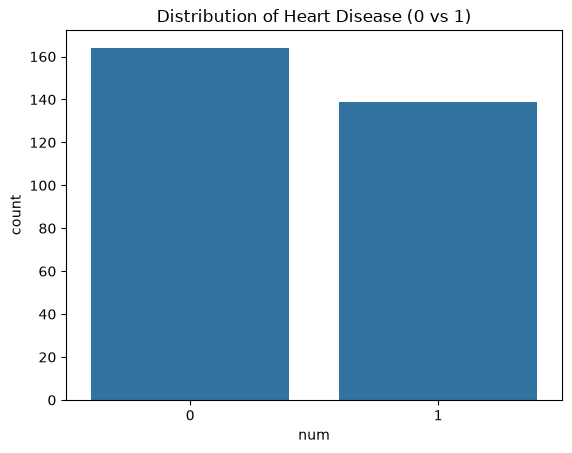

In [4]:
sns.countplot(x=y['num'])
plt.title("Distribution of Heart Disease (0 vs 1)")
plt.show()

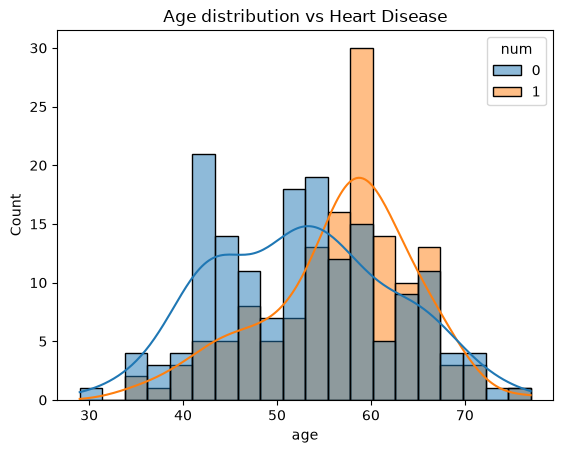

In [5]:
plt.figure()
sns.histplot(data=X, x="age", hue=y['num'], bins=20, kde=True)
plt.title("Age distribution vs Heart Disease")
plt.show()

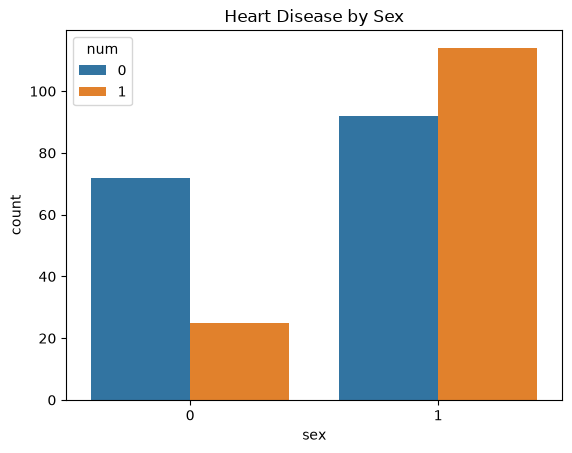

In [6]:
plt.figure()
sns.countplot(x=X['sex'], hue=y['num'])
plt.title("Heart Disease by Sex")
plt.show()

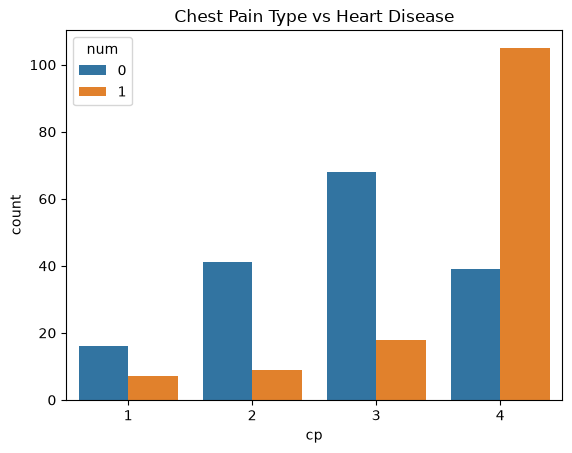

In [7]:
plt.figure()
sns.countplot(x=X['cp'], hue=y['num'])
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

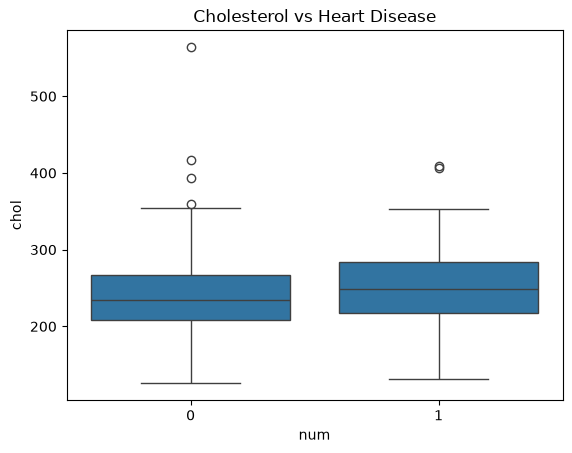

In [8]:
plt.figure()
sns.boxplot(x=y['num'], y=X['chol'])
plt.title("Cholesterol vs Heart Disease")
plt.show()

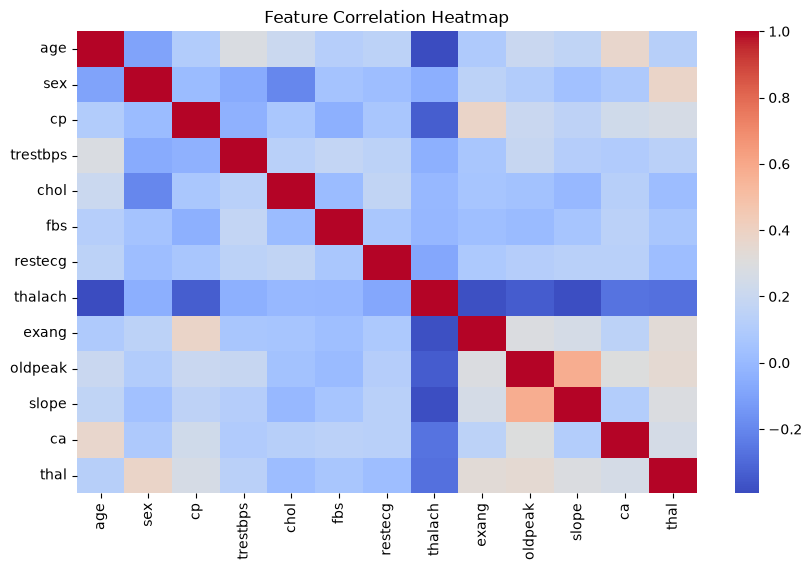

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(X.corr(), annot=False, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y['num'],
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(242, 13) (61, 13)


In [11]:
num_cols = ['age','trestbps','chol','thalach','oldpeak']
cat_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal']

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

In [13]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)

(242, 28)


In [14]:
X_train_p = X_train_processed
X_test_p = X_test_processed
y_train_p = y_train
y_test_p = y_test

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [16]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_p, y_train_p)

rf = RandomForestClassifier()
rf.fit(X_train_p, y_train_p)

svm = SVC(probability=True)
svm.fit(X_train_p, y_train_p)

dt = DecisionTreeClassifier()
dt.fit(X_train_p, y_train_p)

C:\Users\youss\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [17]:
lr_pred = lr.predict(X_test_p)
rf_pred = rf.predict(X_test_p)
svm_pred = svm.predict(X_test_p)
dt_pred = dt.predict(X_test_p)

In [18]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score

print("LR accuracy:", accuracy_score(y_test_p, lr_pred))
print("LR F1:", f1_score(y_test_p, lr_pred))

print("RF accuracy:", accuracy_score(y_test_p, rf_pred))
print("RF F1:", f1_score(y_test_p, rf_pred))

print("SVM accuracy:", accuracy_score(y_test_p, svm_pred))
print("SVM F1:", f1_score(y_test_p, svm_pred))

print("DT accuracy:", accuracy_score(y_test_p, dt_pred))
print("DT F1:", f1_score(y_test_p, dt_pred))

LR accuracy: 0.8360655737704918
LR F1: 0.84375
RF accuracy: 0.8688524590163934
RF F1: 0.8709677419354839
SVM accuracy: 0.8852459016393442
SVM F1: 0.8888888888888888
DT accuracy: 0.7540983606557377
DT F1: 0.7619047619047619


In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

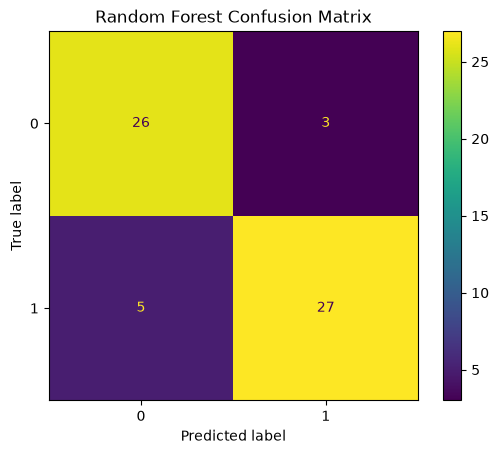

In [20]:
cm = confusion_matrix(y_test_p, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

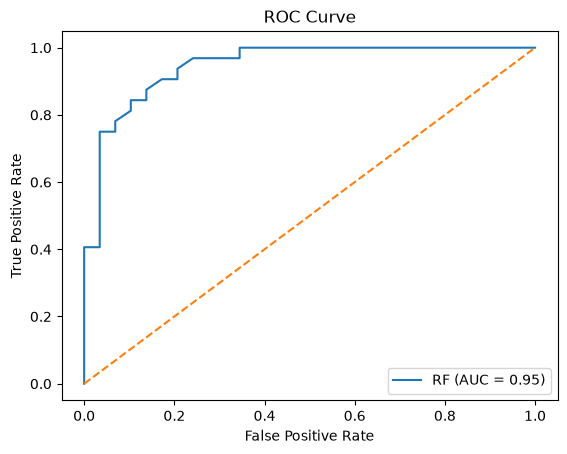

In [21]:
rf_prob = rf.predict_proba(X_test_p)[:,1]

fpr, tpr, _ = roc_curve(y_test_p, rf_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"RF (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [22]:
models = {
    "LogReg": lr,
    "RF": rf,
    "SVM": svm,
    "DT": dt
}

for name, model in models.items():
    pred = model.predict(X_test_p)
    print(name, "F1:", f1_score(y_test_p, pred))

LogReg F1: 0.84375
RF F1: 0.8709677419354839
SVM F1: 0.8888888888888888
DT F1: 0.7619047619047619
